<a href="https://colab.research.google.com/github/hmklahm/ET3112_Assignment02/blob/main/crop_slope_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img = cv.imread('/content/original image.jpg.jpeg', cv.IMREAD_GRAYSCALE)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


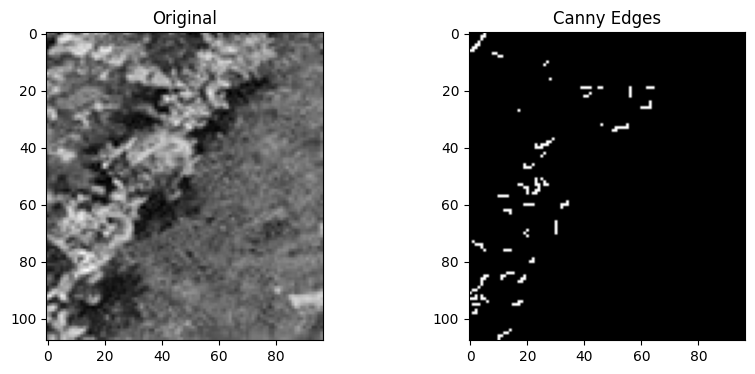

In [3]:
edges = cv.Canny(img, 550, 690)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.show()

In [4]:
indices = np.where(edges != 0)

x = indices[1]
y = indices[0]

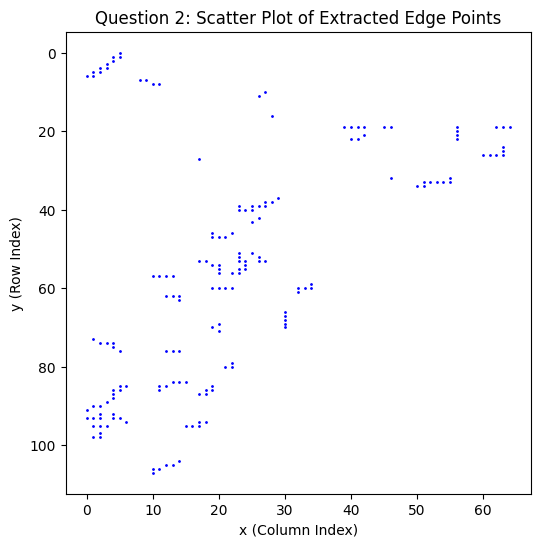

In [5]:
#Question 2
plt.figure(figsize=(6, 6))

plt.scatter(x, y, s=1, color='Blue')


plt.gca().invert_yaxis()

plt.title("Question 2: Scatter Plot of Extracted Edge Points")
plt.xlabel("x (Column Index)")
plt.ylabel("y (Row Index)")
plt.show()

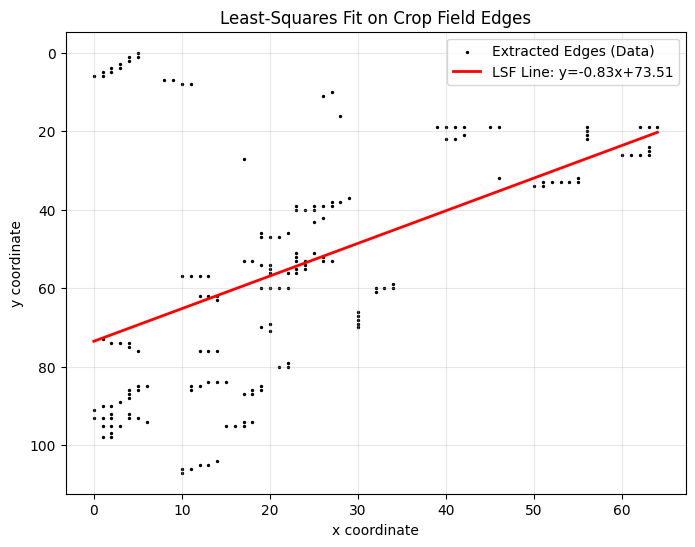

Estimated Slope (m): -0.8319
Estimated Intercept (c): 73.5114


In [6]:
#question 3

X_mat = np.column_stack((x, np.ones(len(x))))

# 2. Solve for parameters (m, c)
m, c = np.linalg.lstsq(X_mat, y, rcond=None)[0]


line_x = np.array([np.min(x), np.max(x)])
line_y = m * line_x + c


plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=2, color='black', label='Extracted Edges (Data)') # Scatter plot of points [cite: 903]
plt.plot(line_x, line_y, color='red', linewidth=2, label=f'LSF Line: y={m:.2f}x+{c:.2f}') # Regression line


plt.gca().invert_yaxis()

plt.title("Least-Squares Fit on Crop Field Edges")
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Estimated Slope (m): {m:.4f}")
print(f"Estimated Intercept (c): {c:.4f}")

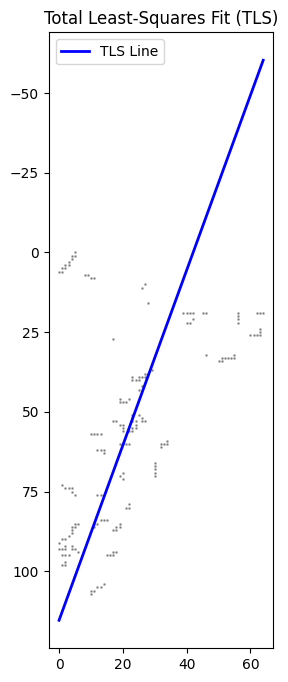

Estimated Crop Field Angle (TLS): -69.97 degrees


In [7]:
# Question 6
x_coords = indices[1]
y_coords = indices[0]
x_mean, y_mean = np.mean(x_coords), np.mean(y_coords)
U = np.column_stack((x_coords - x_mean, y_coords - y_mean))

#Calculate second moment metrix
UTU = np.dot(U.T, U)


eigenvalues, eigenvectors = np.linalg.eigh(UTU)
smallest_eigen_idx = np.argmin(eigenvalues)
a, b = eigenvectors[:, smallest_eigen_idx]

# Slope of line ax + by = d is m = -a/b
m_tls = -a / b
c_tls = y_mean - m_tls * x_mean

# Generate line for plotting
line_y_tls = m_tls * line_x + c_tls

plt.figure(figsize=(8, 8))
plt.scatter(x_coords, y_coords, s=1, color='black', alpha=0.3)
plt.plot(line_x, line_y_tls, color='blue', linewidth=2, label='TLS Line')
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().invert_yaxis()
plt.legend()
plt.title("Total Least-Squares Fit (TLS)")
plt.show()

# Question 7: Estimated Angle theta
theta_tls = np.degrees(np.arctan(m_tls))
print(f"Estimated Crop Field Angle (TLS): {theta_tls:.2f} degrees")

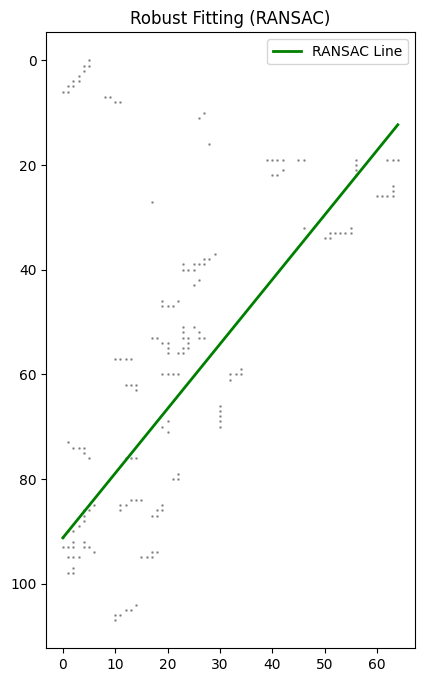

Estimated Crop Field Angle (RANSAC): -50.96 degrees


In [8]:
from sklearn.linear_model import RANSACRegressor

# Question 10
# find the best fit
ransac = RANSACRegressor()
ransac.fit(x_coords.reshape(-1, 1), y_coords)

# Get parameters
m_r = ransac.estimator_.coef_[0]
c_r = ransac.estimator_.intercept_
theta_r = np.degrees(np.arctan(m_r))
line_x = np.linspace(np.min(x_coords), np.max(x_coords), 100)

plt.figure(figsize=(8, 8))
plt.scatter(x_coords, y_coords, s=1, color='black', alpha=0.3)
plt.plot(line_x, m_r * line_x + c_r, color='green', linewidth=2, label='RANSAC Line')
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().invert_yaxis()
plt.legend()
plt.title("Robust Fitting (RANSAC)")
plt.show()

print(f"Estimated Crop Field Angle (RANSAC): {theta_r:.2f} degrees")